In [ ]:
!pip install -q pytorch-lightning wandb kagglehub

In [ ]:
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import wandb

from PIL import Image
import kagglehub

import warnings
warnings.filterwarnings("ignore")

In [ ]:
HOME = os.getcwd()
os.environ["DISABLE_COLAB_CACHE"] = "True"

In [ ]:
path = kagglehub.dataset_download(
    handle="trainingdatapro/roads-segmentation-dataset",
    force_download=True,
    output_dir=os.path.join(HOME, "data")
)

100%|██████████| 16.0M/16.0M [00:00<00:00, 80.9MB/s]

Extracting files...


In [ ]:
data_root = path

images_dir = os.path.join(data_root, "images")
masks_dir = os.path.join(data_root, "masks")

if not os.path.exists(images_dir):
    # Пробуем другие возможные имена
    for d in os.listdir(data_root):
        if "image" in d.lower():
            images_dir = os.path.join(data_root, d)
        if "mask" in d.lower():
            masks_dir = os.path.join(data_root, d)

In [ ]:
print("Папка с изображениями:", images_dir)
print("Папка с масками:", masks_dir)

Папка с изображениями: /content/data/images
Папка с масками: /content/data/masks


Определение класса Dataset и трансформаций

In [ ]:
class RoadSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.images = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) +
                             glob.glob(os.path.join(image_dir, "*.png")) +
                             glob.glob(os.path.join(image_dir, "*.jpeg")))
        self.masks = []
        for img_path in self.images:
            basename = os.path.basename(img_path).rsplit('.', 1)[0]
            mask_path = os.path.join(mask_dir, basename + ".png")
            if not os.path.exists(mask_path):
                for ext in [".jpg", ".jpeg", ".png"]:
                    candidate = os.path.join(mask_dir, basename + ext)
                    if os.path.exists(candidate):
                        mask_path = candidate
                        break
            self.masks.append(mask_path)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")
        img = np.array(img)
        mask = np.array(mask)
        # Бинаризация и приведение к float32
        mask = (mask > 128).astype(np.float32)   # shape: (H, W)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]    # тензор (3, H, W)
            mask = augmented["mask"]    # тензор (H, W)

        # Добавляем канал для маски после всех трансформаций
        mask = mask.unsqueeze(0)   # (1, H, W)
        return img, mask

Создание DataLoader и разделение на train/val


In [ ]:
# Полный датасет
dataset = RoadSegmentationDataset(images_dir, masks_dir, transform=transform)
print(f"Всего образцов: {len(dataset)}")

# Разделение 80/20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

Всего образцов: 31


Определение модели U-Net (ConvBlock и UNET)

In [ ]:
class ConvBlock(pl.LightningModule):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNET(pl.LightningModule):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128], learning_rate=1e-3):
        super().__init__()
        self.learning_rate = learning_rate
        self.down = nn.ModuleList()
        self.up = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        for feature in features:
            self.down.append(ConvBlock(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = ConvBlock(features[-1], features[-1]*2)

        # Decoder
        for feature in reversed(features):
            self.up.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.up.append(ConvBlock(feature*2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        self.loss_fn = nn.BCEWithLogitsLoss()

        # Метрики
        self.train_loss = []
        self.val_loss = []
        self.train_dice = []
        self.val_dice = []

    def forward(self, x):
        skip_connections = []
        for down in self.down:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.up), 2):
            x = self.up[idx](x)
            skip = skip_connections[idx//2]
            if x.shape != skip.shape:
                x = transforms.functional.resize(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.up[idx+1](x)

        return self.final_conv(x)

    def dice_coef(self, pred, target, smooth=1e-6):
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()
        intersection = (pred * target).sum()
        return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        dice = self.dice_coef(logits, y)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_dice', dice, prog_bar=True)
        self.train_loss.append(loss)
        self.train_dice.append(dice)
        return loss

    def on_train_epoch_end(self):
        avg_loss = torch.stack(self.train_loss).mean()
        avg_dice = torch.stack(self.train_dice).mean()
        self.log('epoch_train_loss', avg_loss)
        self.log('epoch_train_dice', avg_dice)
        self.train_loss.clear()
        self.train_dice.clear()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        dice = self.dice_coef(logits, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_dice', dice, prog_bar=True)
        self.val_loss.append(loss)
        self.val_dice.append(dice)
        return loss

    def on_validation_epoch_end(self):
        avg_loss = torch.stack(self.val_loss).mean()
        avg_dice = torch.stack(self.val_dice).mean()
        self.log('epoch_val_loss', avg_loss)
        self.log('epoch_val_dice', avg_dice)
        self.val_loss.clear()
        self.val_dice.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss', 'frequency': 1}
        }

Инициализация модели и Trainer

In [ ]:
# Создание модели
model = UNET(in_channels=3, out_channels=1, learning_rate=1e-3)

# Callback для сохранения лучшей модели по Dice
checkpoint_callback = ModelCheckpoint(
    monitor='val_dice',
    mode='max',
    save_top_k=1,
    filename='best-model-{epoch:02d}-{val_dice:.4f}'
)

# Trainer
trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback],
    log_every_n_steps=10
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Момент истины

In [ ]:
trainer.fit(model, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ down       │ ModuleList        │  287 K │ train │     0 │
│ 1 │ up         │ ModuleList        │  753 K │ train │     0 │
│ 2 │ pool       │ MaxPool2d         │      0 │ train │     0 │
│ 3 │ bottleneck │ ConvBlock         │  885 K │ train │     0 │
│ 4 │ final_conv │ Conv2d            │     33 │ train │     0 │
│ 5 │ loss_fn    │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 64                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Что получили

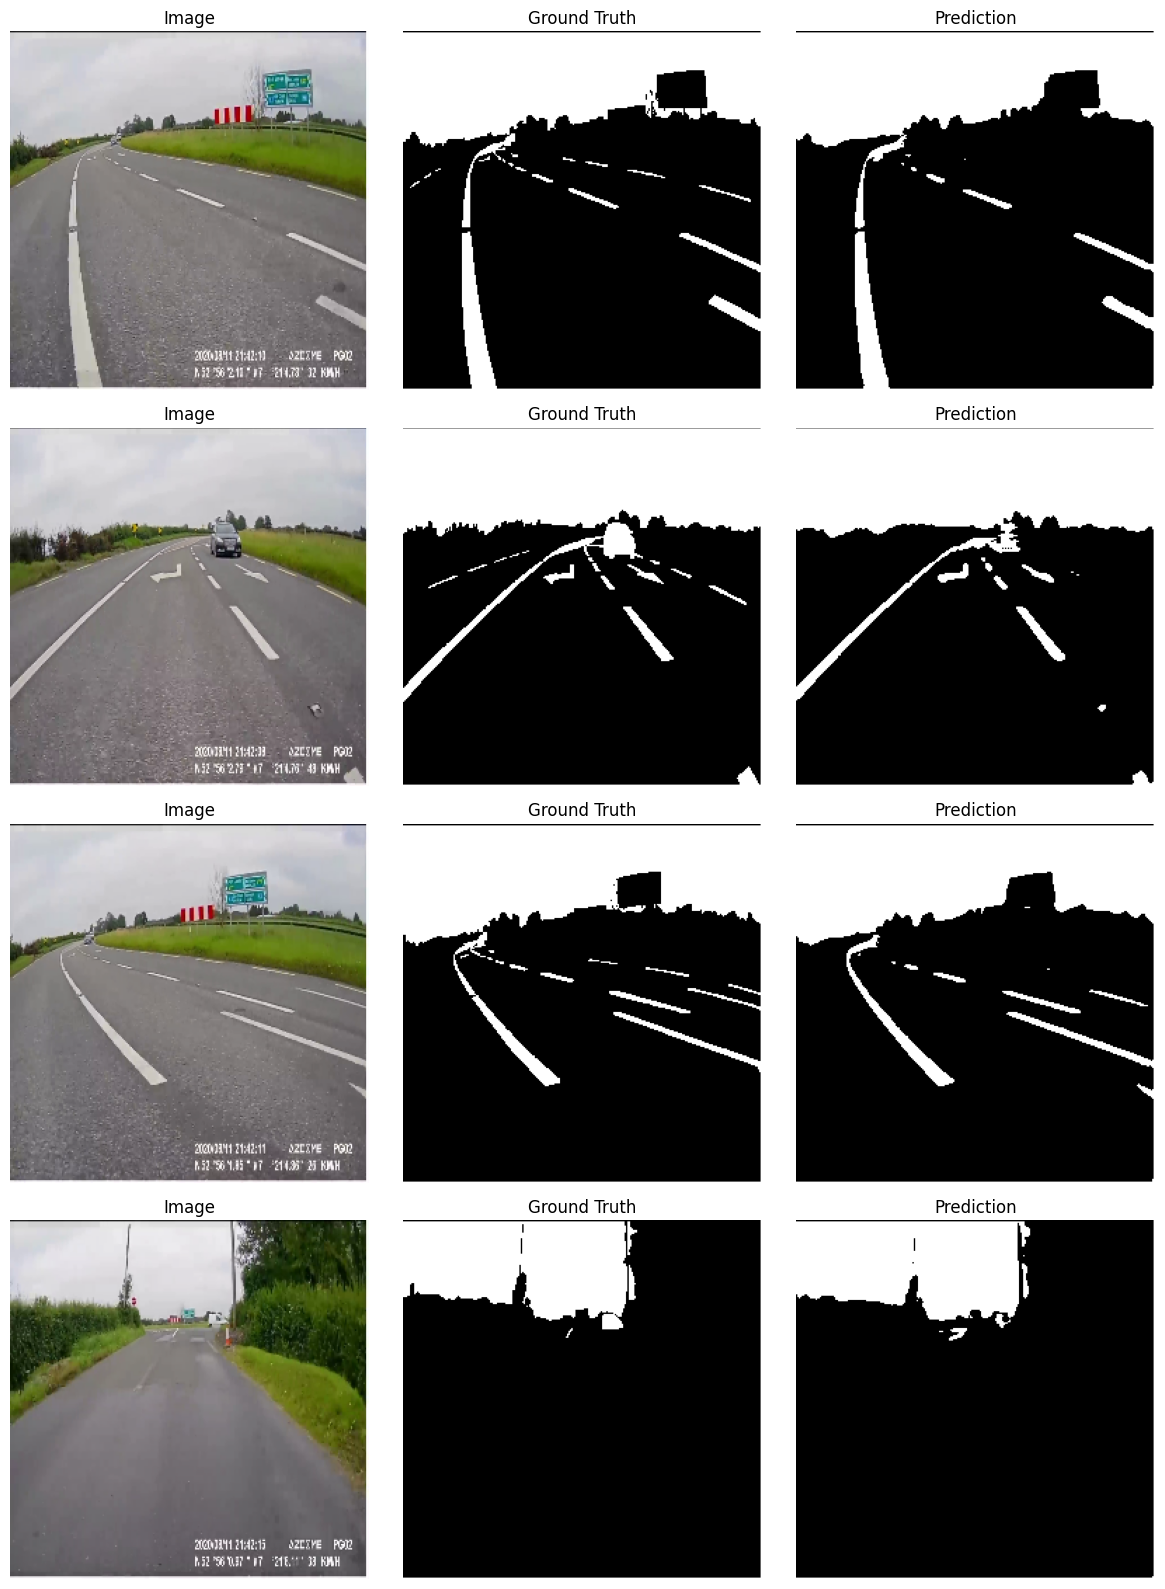

In [ ]:
def predict_mask(model, image, device):
    model.eval()
    model.to(device)
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(image)
        prob = torch.sigmoid(logits)
        mask = (prob > 0.5).float().cpu().squeeze().numpy()
    return mask

# Выбираем устройство (CPU, если CUDA недоступна)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()
model.to(device)

n_samples = 4
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))

for i in range(n_samples):
    img, true_mask = val_dataset[i]
    # Денормализация
    img_disp = img.cpu().numpy().transpose(1,2,0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_disp = std * img_disp + mean
    img_disp = np.clip(img_disp, 0, 1)

    pred_mask = predict_mask(model, img, device)

    axes[i,0].imshow(img_disp)
    axes[i,0].set_title("Image")
    axes[i,0].axis('off')
    axes[i,1].imshow(true_mask.squeeze(), cmap='gray')
    axes[i,1].set_title("Ground Truth")
    axes[i,1].axis('off')
    axes[i,2].imshow(pred_mask, cmap='gray')
    axes[i,2].set_title("Prediction")
    axes[i,2].axis('off')

plt.tight_layout()
plt.show()

цифры....

Средний IoU на валидационной выборке: 0.9536
Медианный IoU: 0.9554
Минимальный IoU: 0.9471
Максимальный IoU: 0.9620


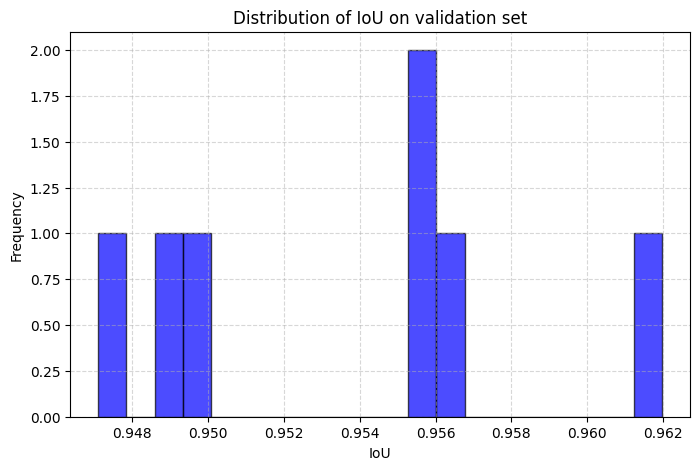

In [ ]:
def iou_score(pred_mask, true_mask, smooth=1e-6):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    return (intersection + smooth) / (union + smooth)

model.eval()
model.to(device)

ious = []
for img, true_mask in val_dataset:
    pred_mask = predict_mask(model, img, device)
    true_mask_np = true_mask.squeeze().cpu().numpy()
    true_mask_bin = (true_mask_np > 0.5).astype(np.uint8)
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)

    iou = iou_score(pred_mask_bin, true_mask_bin)
    ious.append(iou)

mean_iou = np.mean(ious)
print(f"Средний IoU на валидационной выборке: {mean_iou:.4f}")
print(f"Медианный IoU: {np.median(ious):.4f}")
print(f"Минимальный IoU: {np.min(ious):.4f}")
print(f"Максимальный IoU: {np.max(ious):.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(ious, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('IoU')
plt.ylabel('Frequency')
plt.title('Distribution of IoU on validation set')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

А теперь другая дата
KITTI-Road https://www.kaggle.com/datasets/sakshaymahna/kittiroadsegmentation

In [ ]:
import os
import kagglehub

kitti_path = kagglehub.dataset_download(
    "sakshaymahna/kittiroadsegmentation",
    force_download=True
)
print(f"KITTI dataset downloaded to: {kitti_path}")

100%|██████████| 305M/305M [00:02<00:00, 143MB/s]

Extracting files...


KITTI dataset downloaded to: /root/.cache/kagglehub/datasets/sakshaymahna/kittiroadsegmentation/versions/1


проверка

In [ ]:
import os

print("Содержимое корня:", os.listdir(kitti_path))
for subdir in ["training", "testing"]:
    path = os.path.join(kitti_path, subdir)
    if os.path.exists(path):
        print(f"\n--- {subdir} ---")
        for item in os.listdir(path):
            print(item)
        img_dir = os.path.join(path, "image_2")
        if os.path.exists(img_dir):
            print(f"\nПримеры изображений в {img_dir}:")
            for f in os.listdir(img_dir)[:5]:
                print(f"  {f}")
        masks_dir = os.path.join(path, "gt_image_2")
        if os.path.exists(masks_dir):
            print(f"\nПримеры масок в {masks_dir}:")
            for f in os.listdir(masks_dir)[:5]:
                print(f"  {f}")

Содержимое корня: ['training', 'testing']

--- training ---
image_2
calib
gt_image_2

Примеры изображений в /root/.cache/kagglehub/datasets/sakshaymahna/kittiroadsegmentation/versions/1/training/image_2:
  umm_000087.png
  uu_000045.png
  um_000053.png
  uu_000026.png
  umm_000053.png

Примеры масок в /root/.cache/kagglehub/datasets/sakshaymahna/kittiroadsegmentation/versions/1/training/gt_image_2:
  um_road_000068.png
  um_road_000005.png
  uu_road_000077.png
  uu_road_000058.png
  umm_road_000080.png

--- testing ---
solidYellowLeft.mp4
harder_challenge_video.mp4
challenge.mp4
project_video.mp4
solidWhiteRight.mp4
challenge_video.mp4


Создание Dataset класса для KITTI



In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import os

class KITTIRoadDataset(Dataset):
    def __init__(self, root_dir, split='training', transform=None):
        self.transform = transform
        self.images_dir = os.path.join(root_dir, split, 'image_2')
        self.masks_dir = os.path.join(root_dir, split, 'gt_image_2')
        self.images = sorted([f for f in os.listdir(self.images_dir) if f.endswith('.png')])
        self.pairs = []
        for img_fname in self.images:
            basename = os.path.splitext(img_fname)[0]
            parts = basename.split('_')
            if len(parts) == 2:
                prefix, number = parts
                mask_fname = f"{prefix}_road_{number}.png"
            else:
                mask_fname = basename + "_road.png"
            mask_path = os.path.join(self.masks_dir, mask_fname)
            if os.path.exists(mask_path):
                self.pairs.append((os.path.join(self.images_dir, img_fname), mask_path))
            else:
                print(f"Warning: mask not found for {img_fname}, skipping")
        print(f"Loaded {len(self.pairs)} image-mask pairs from {split} set")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        # Load image (RGB)
        image = np.array(Image.open(img_path).convert('RGB'))
        # Load mask (color)
        mask_color = np.array(Image.open(mask_path))
        # Resize mask to image size if needed (should not be needed if naming is consistent)
        if image.shape[:2] != mask_color.shape[:2]:
            mask_color = np.array(Image.fromarray(mask_color).resize((image.shape[1], image.shape[0]), Image.NEAREST))
        # Create binary mask: road = magenta (255,0,255) -> 1, else 0
        mask = np.zeros((mask_color.shape[0], mask_color.shape[1]), dtype=np.float32)
        magenta = (mask_color[:,:,0] == 255) & (mask_color[:,:,1] == 0) & (mask_color[:,:,2] == 255)
        mask[magenta] = 1.0
        # Add channel dimension -> (1, H, W)
        mask = np.expand_dims(mask, axis=0)

        # Apply transformations (Resize, Normalize, ToTensor)
        if self.transform:
            # Ensure mask is (H, W) because Albumentations expects 2D for masks
            transformed = self.transform(image=image, mask=mask.squeeze(0))
            image = transformed['image']     # (C, H, W)
            mask = transformed['mask']       # (H, W)
            mask = mask.unsqueeze(0)         # (1, H, W)
        else:
            image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
            mask = torch.from_numpy(mask).float()

        return image, mask

Настройка трансформаций

In [ ]:
TARGET_SIZE = 256

test_transform = A.Compose([
    A.Resize(height=TARGET_SIZE, width=TARGET_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)   # отключаем проверку размеров внутри Compose

Загрузка тестовой выборки

In [ ]:
kitti_root = kitti_path   # или укажите путь вручную
test_dataset = KITTIRoadDataset(kitti_root, split='training', transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
print(f"Total test samples: {len(test_dataset)}")

Loaded 289 image-mask pairs from training set
Total test samples: 289


Оценка модели на KITTI

In [ ]:
import numpy as np

def iou_score(pred_mask, true_mask, smooth=1e-6):
    pred_bin = (pred_mask > 0.5).astype(np.uint8)
    # если true_mask 3D, берем первый канал или сжимаем
    if true_mask.ndim == 3:
        true_bin = (true_mask > 0.5).astype(np.uint8)
        if true_bin.shape[2] > 1:
            true_bin = true_bin[:,:,0]
    else:
        true_bin = (true_mask > 0.5).astype(np.uint8)
    # убеждаемся, что размеры совпадают
    if pred_bin.shape != true_bin.shape:
        # если true_bin имеет лишнюю размерность, сжимаем
        if true_bin.ndim > 2:
            true_bin = true_bin.squeeze()
    assert pred_bin.shape == true_bin.shape, f"Shape mismatch: {pred_bin.shape} vs {true_bin.shape}"
    intersection = np.logical_and(pred_bin, true_bin).sum()
    union = np.logical_or(pred_bin, true_bin).sum()
    return (intersection + smooth) / (union + smooth)

def dice_score(pred_mask, true_mask, smooth=1e-6):
    pred_bin = (pred_mask > 0.5).astype(np.uint8)
    if true_mask.ndim == 3:
        true_bin = (true_mask > 0.5).astype(np.uint8)
        if true_bin.shape[2] > 1:
            true_bin = true_bin[:,:,0]
    else:
        true_bin = (true_mask > 0.5).astype(np.uint8)
    if pred_bin.shape != true_bin.shape:
        true_bin = true_bin.squeeze()
    intersection = np.logical_and(pred_bin, true_bin).sum()
    total = pred_bin.sum() + true_bin.sum()
    return (2. * intersection + smooth) / (total + smooth)

In [ ]:
from tqdm import tqdm

model.eval()
ious = []
dices = []

for i in tqdm(range(len(test_dataset))):
    img, true_mask = test_dataset[i]                # true_mask: (1, H, W) tensor
    pred_mask = predict_mask(model, img, device)   # (H, W) numpy
    # Convert true_mask to numpy and remove channel dim
    true_np = true_mask.squeeze().cpu().numpy()    # (H, W) or (H, W, ?)
    # Если true_np имеет 3 измерения (например, (H,W,1)), преобразуем
    if true_np.ndim == 3 and true_np.shape[-1] == 1:
        true_np = true_np[..., 0]
    iou = iou_score(pred_mask, true_np)
    dice = dice_score(pred_mask, true_np)
    ious.append(iou)
    dices.append(dice)

print(f"Mean IoU: {np.mean(ious):.4f}")
print(f"Mean Dice: {np.mean(dices):.4f}")
print(f"Median IoU: {np.median(ious):.4f}")
print(f"Median Dice: {np.median(dices):.4f}")

100%|██████████| 289/289 [01:59<00:00,  2.43it/s]

Mean IoU: 0.1481
Mean Dice: 0.2345
Median IoU: 0.0844
Median Dice: 0.1557


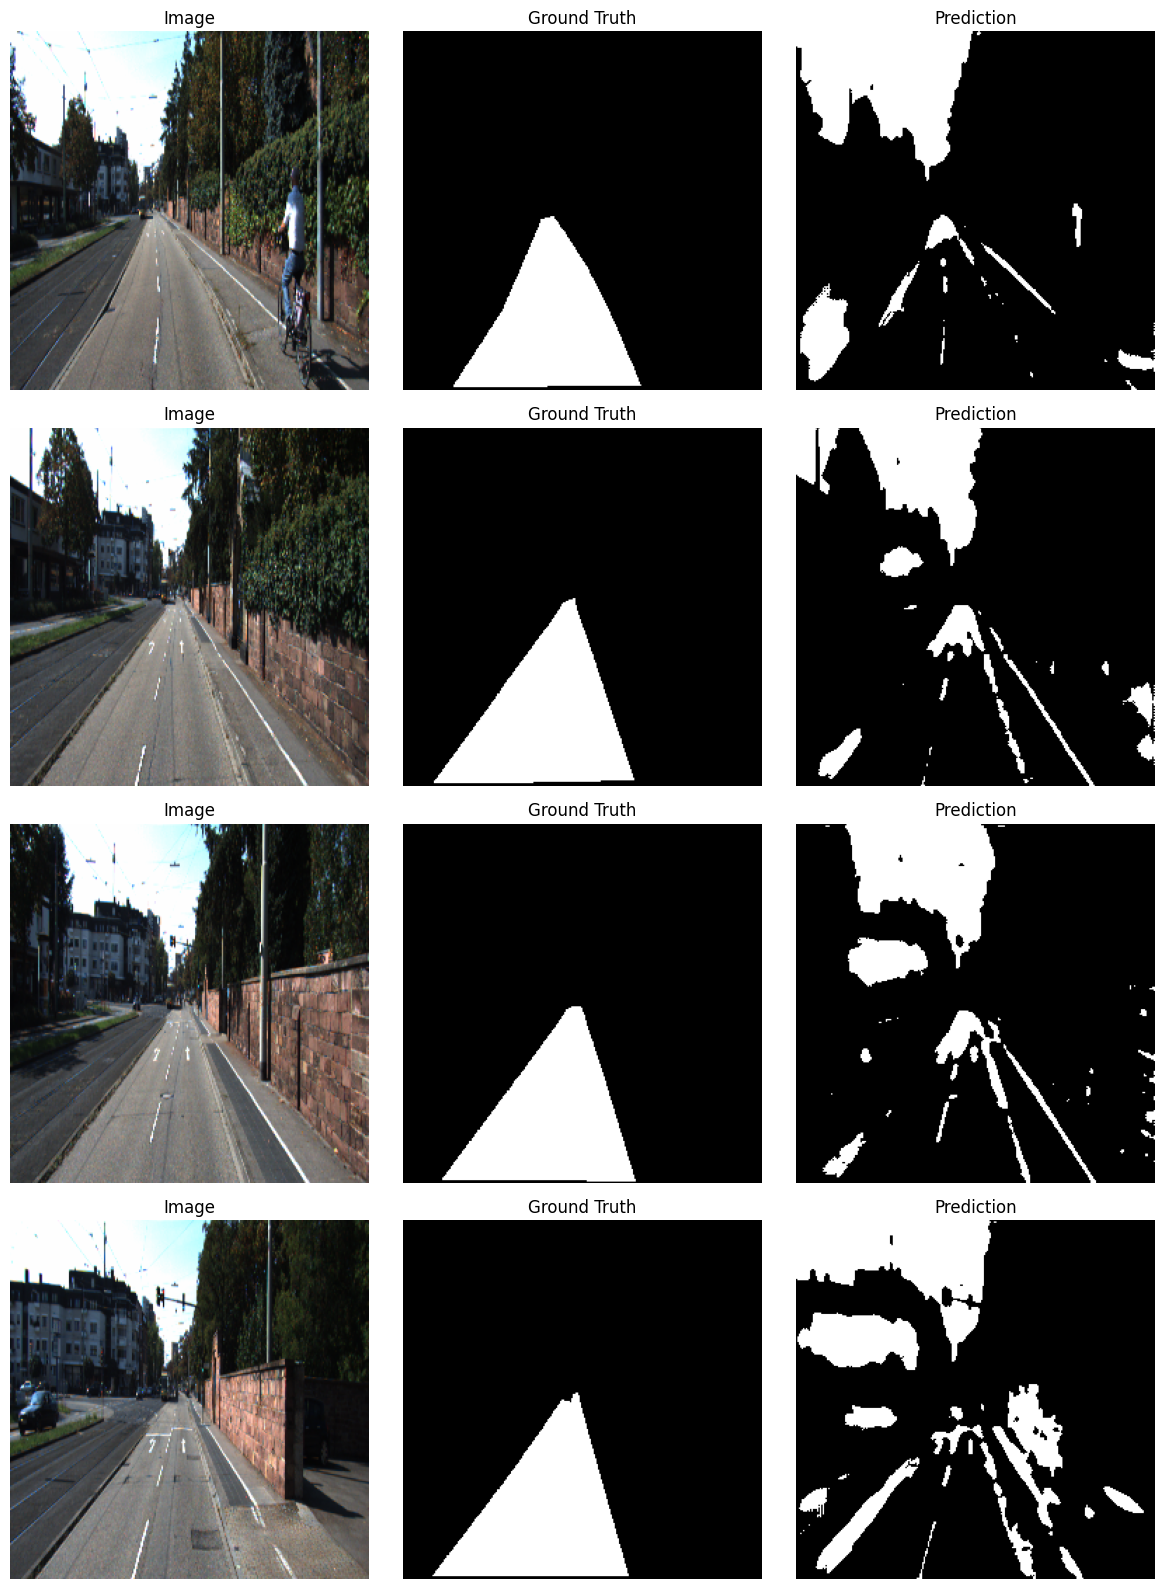

In [ ]:
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.cpu().numpy().transpose(1,2,0)
    img = std * img + mean
    return np.clip(img, 0, 1)

n_samples = 4
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))

for i in range(n_samples):
    img, true_mask = test_dataset[i]
    pred_mask = predict_mask(model, img, device)  # (H, W)
    true_np = true_mask.squeeze().cpu().numpy()   # (H, W)
    if true_np.ndim == 3:
        true_np = true_np[:,:,0]
    axes[i,0].imshow(denormalize(img))
    axes[i,0].set_title("Image")
    axes[i,0].axis('off')
    axes[i,1].imshow(true_np, cmap='gray')
    axes[i,1].set_title("Ground Truth")
    axes[i,1].axis('off')
    axes[i,2].imshow(pred_mask, cmap='gray')
    axes[i,2].set_title("Prediction")
    axes[i,2].axis('off')
plt.tight_layout()
plt.show()

шла
к


In [ ]:
import os

kitti_root = kitti_path   # или ваш путь
test_dataset = KITTIRoadDataset(kitti_root, split='training', transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

Loaded 289 image-mask pairs from training set
